(3043, 6)
count    3043.000000
mean       92.088071
std       106.493169
min         1.000000
25%        34.000000
50%        65.000000
75%       113.000000
max      2197.000000
Name: text, dtype: float64
count    3043.000000
mean       20.887282
std       141.176139
min         0.000000
25%         0.000000
50%         1.000000
75%         8.000000
max      5360.000000
Name: like_count, dtype: float64
text
Tama                                                                                               10
❤❤❤                                                                                                 5
💚💚💚                                                                                                 4
🤔                                                                                                   4
​@@JuanManuel-t9kBugok kaya nagkaroon ng West Philippines Sea sa google dahil kay marcoleta 🥰😘😍     4
😂😂😂😂😂                                                                          

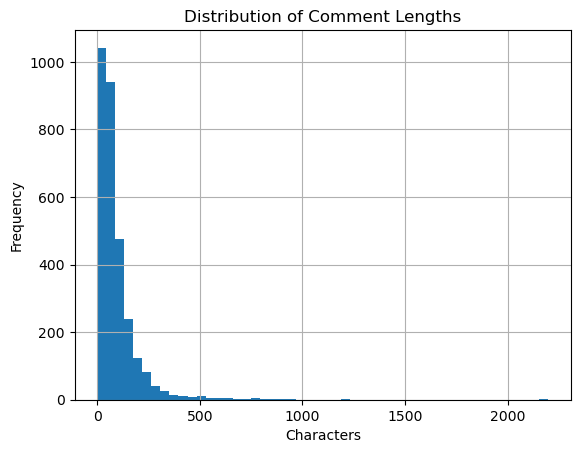

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0:
['sa', 'senators', 'people', 'mga', 'tama', 'senate', 'impeachment', 'kayo', 'ang', 'po']
---
Topic 1:
['philippines', 'job', 'duterte', 'si', 'senate', 'hontiveros', 'time', 'philhealth', 'public', 'good']
---
Topic 2:
['ni', 'yan', 'hindi', 'pa', 'mo', 'mga', 'ng', 'sa', 'ang', 'na']
---
Topic 3:
['hindi', 'yan', 'lang', 'mo', 'ka', 'mga', 'na', 'ng', 'ang', 'sa']
---
Topic 4:
['chiz', 'po', 'bless', 'god', 'sir', 'si', 'ka', 'senator', 'marcoleta', 'sen']
---


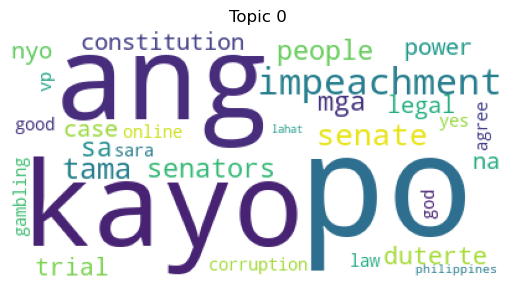

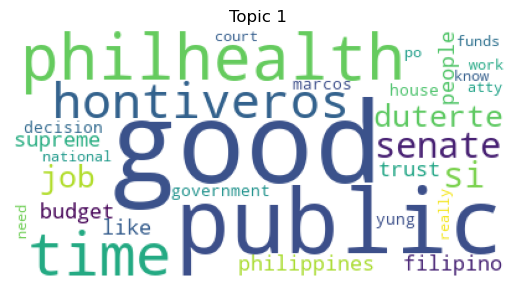

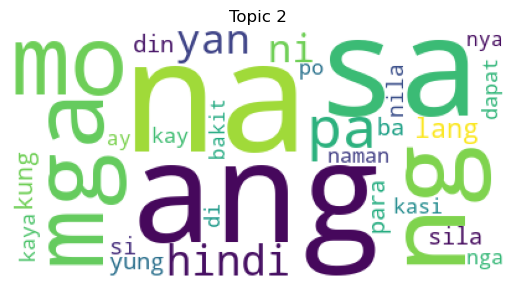

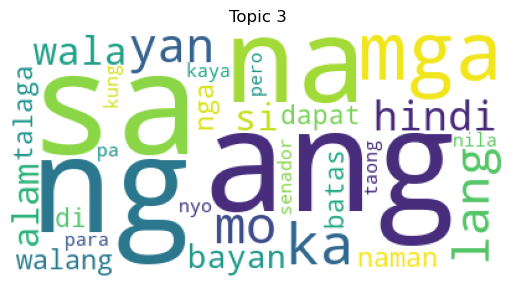

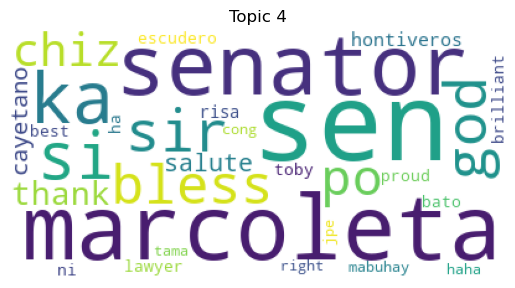

In [1]:
# Load Data
import pandas as pd

# base sheet of scraped comments
comments = pd.read_excel("method-1-youtube/scripts/youtube_comments.xlsx", sheet_name="youtube_base")
print(comments.shape)
comments.head()

# Exploratory Data Analysis
# basic stats
print(comments['text'].str.len().describe())
print(comments['like_count'].describe())

# Most common comments
print(comments['text'].value_counts().head(10))

# distribution of comment lengths
import matplotlib.pyplot as plt
comments['text'].str.len().hist(bins=50)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# nlp Preprocessing
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

comments['processed_text'] = comments['text'].apply(clean_text)
comments[['text','processed_text']].head()

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# vectorize
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(comments['processed_text'])

# fit LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# print top words per topic
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([terms[i] for i in topic.argsort()[-10:]])
    print("---")

# visualize topics with word clouds
from wordcloud import WordCloud

for idx, topic in enumerate(lda.components_):
    plt.figure()
    plt.imshow(WordCloud(background_color='white').fit_words({terms[i]: topic[i] for i in topic.argsort()[-30:]}))
    plt.axis("off")
    plt.title(f"Topic {idx}")
    plt.show()

# Assign Topics to Comments
comment_topics = lda.transform(X).argmax(axis=1)
comments['topic'] = comment_topics
comments[['text','topic']].head(20)

# Save results
comments.to_excel("youtube_comments_with_topics.xlsx", index=False)


## Exploratory data Analysis
- Number of comments: 3043
- distribution of lengths is skewed (most under 200 characters)
- Most common words include political names (Risa (hontiveros), Raffy (tulfo), etc.)

## Topic Modeling Results
- Topic 0: Support for Risa Hontiveros
- Topic 1: Criticism & comparisons with other senators
- Topic 2: Conversational fillers in tagalog
- Topic 3: political commentary in general
- Topic 4: Mentions of senators (Chiz, Marcoleta, etc.)


In [2]:
!pip install scikit-learn

In [3]:
!pip install pyLDAvis

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pyLDAvis
import numpy as np

In [5]:
len(lda.components_)

5

In [6]:
lda.components_

array([[0.20000796, 0.2000028 , 0.2000174 , ..., 0.20063027, 0.20002277,
        0.20001549],
       [0.202038  , 0.20000363, 1.85726936, ..., 0.20002328, 0.20002813,
        4.19055387],
       [2.19481804, 0.20000097, 1.36033197, ..., 0.20293291, 6.19810331,
        0.20135975],
       [0.20000259, 2.19998915, 0.20137286, ..., 3.19907905, 0.20182382,
        0.20365069],
       [0.20313341, 0.20000344, 4.38100841, ..., 1.1973345 , 0.20002197,
        0.2044202 ]])

In [7]:
lda.components_[0].argsort()[-15:]

array([1839, 1306, 2090, 2653,  592, 2270, 2355, 2001, 1590, 2549, 2352,
        975, 1185,   89, 2067])

In [8]:
comments

,title,link,date_published,text,like_count,reply_parent_id,processed_text,topic
0,I really admire Sen. Risa&#39;s calm and wise ...,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-24T15:48:54Z,I really admire Sen. Risa's calm and wise appr...,406,NaN,really admire sen risas calm wise approach que...,0
1,Very pro not so palengkera like Legarda 😂,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-27T16:29:28Z,Very pro not so palengkera like Legarda 😂,2,UgwdNtAh7g0iT4uV8k94AaABAg,pro palengkera like legarda,1
2,Sen Hontiveros proves she deserves her spot in...,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-22T07:16:34Z,Sen Hontiveros proves she deserves her spot in...,5360,NaN,sen hontiveros proves deserves spot senate,1
3,how about sen raffy?,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-22T09:51:42Z,how about sen raffy?,78,Ugz3t5SAfz3h9CzEE7x4AaABAg,sen raffy,1
4,PROUD AKO BINOTO KO YAN SI HONTIVEROS!!! di ak...,https://www.youtube.com/watch?v=Gdaizp5uXb4&lc...,2024-05-22T09:58:40Z,PROUD AKO BINOTO KO YAN SI HONTIVEROS!!! di ak...,227,Ugz3t5SAfz3h9CzEE7x4AaABAg,proud ako binoto ko yan si hontiveros di ako n...,4
...,...,...,...,...,...,...,...,...
3038,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T03:33:27Z,O di ba? Hindi man si Sen Marcolleta sa eat Bu...,5,NaN,di ba hindi man si sen marcolleta sa eat bulag...,4
3039,Salute Sen.Marcoleta,https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-07T05:58:03Z,Salute Sen.Marcoleta,2,NaN,salute senmarcoleta,4
3040,"Senator Marcoleta, my two thumbs up for you. Y...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-06T17:43:46Z,"Senator Marcoleta, my two thumbs up for you. Y...",9,NaN,senator marcoleta two thumbs smartest senator ...,1
3041,"Yes now, l know why the imp. Was the un contit...",https://www.youtube.com/watch?v=JOpVsKRf_IU&lc...,2025-08-08T01:17:36Z,"Yes now, l know why the imp. Was the un contit...",1,NaN,yes l know imp un contitutional complain one,0


In [9]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
doc_term_matrix=vectorizer.fit_transform(comments['processed_text'])

In [10]:
topic_term_matrix = lda.components_
doc_topic_matrix = lda.transform(doc_term_matrix)

In [11]:
vocab = vectorizer.get_feature_names_out()
doc_lengths = [len(doc) for doc in comments['processed_text']]
term_freqs = doc_term_matrix.sum(axis=0)
term_freqs = np.array(term_freqs).flatten()
vis_data = pyLDAvis.prepare(topic_term_matrix, doc_topic_matrix, doc_lengths, vocab, term_freqs)

pyLDAvis.display(vis_data)

/home/julyanna/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=9554) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/julyanna/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=9554) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/julyanna/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=9554) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/julyanna/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=9554) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/julyanna/anaconda3/lib/python3.13/site-packages/joblib/externals/l